# Monitor the training process -- Weather Prediction (PyTorch)

We work on a regression task (weather prediction):
- how to create a neural network
- how to optimize the model
- how to monitor the training process
- how to detect (or avoid) overfitting
- common options to improve the model performance

## 0. Import packages and modules

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn

import torch
import torch.nn as nn

import datetime

print(f"PyTorch version: {torch.__version__}")
print(f"Sklearn version: {sklearn.__version__}")

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu128
Sklearn version: 1.8.0
Using device: cuda


## 1.Formulate/Outline the problem: Weather Prediction

<img src="https://enccs.github.io/deep-learning-intro/_images/03_weather_prediction_dataset_map.png" alt="drawing" width="720"/>

## 2. Identify inputs and outputs

In [2]:
data = pd.read_csv("https://zenodo.org/record/5071376/files/weather_prediction_dataset_light.csv?download=1")
data

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
0,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,...,-15.2,-17.0,-13.4,0.97,1.0275,0.25,0.04,8.5,7.2,9.8
1,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,...,-13.7,-15.0,-12.3,0.99,1.0293,0.17,0.16,7.9,6.6,9.2
2,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,...,-9.2,-12.5,-5.8,0.91,1.0267,0.27,0.00,8.1,6.6,9.6
3,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,...,-5.6,-7.0,-4.2,0.95,1.0222,0.11,0.44,8.6,6.4,10.8
4,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,...,-7.6,-9.4,-5.8,0.95,1.0209,0.39,0.04,8.0,6.4,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3649,20091228,12,7,0.82,1.0084,0.28,0.42,0.3,3.2,1.0,...,-15.1,-16.2,-14.0,0.95,1.0011,0.22,1.50,6.2,1.8,10.6
3650,20091229,12,7,0.92,1.0028,0.22,1.68,0.2,4.5,2.4,...,-10.9,-14.4,-7.3,0.89,0.9966,0.24,0.40,10.4,6.2,14.5
3651,20091230,12,8,0.92,0.9979,0.07,1.54,0.0,8.5,7.5,...,-6.6,-7.6,-5.6,0.88,0.9939,0.24,1.00,10.0,8.7,11.3
3652,20091231,12,7,0.93,0.9958,0.17,0.57,0.1,6.6,4.3,...,-7.2,-8.9,-5.4,0.88,0.9933,0.58,0.02,8.5,6.2,10.9


In [3]:
data.describe()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
count,3.654000e+03,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,...,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000
mean,2.004568e+07,6.520799,5.418446,0.745107,1.017876,1.330380,0.234849,4.661193,11.022797,6.989135,...,-4.626327,-6.884319,-2.352244,0.781872,1.016639,1.369787,0.186100,12.205802,7.860536,16.551779
std,2.874287e+04,3.450083,2.325497,0.107788,0.007962,0.935348,0.536267,4.330112,7.414754,6.653356,...,6.987080,7.120333,6.972886,0.115572,0.018885,0.926472,0.422151,6.467155,5.692256,7.714924
min,2.000010e+07,1.000000,0.000000,0.380000,0.985600,0.050000,0.000000,0.000000,-9.300000,-16.000000,...,-26.600000,-30.300000,-24.700000,0.330000,0.000300,0.050000,0.000000,-6.200000,-13.000000,-3.100000
25%,2.002070e+07,4.000000,4.000000,0.670000,1.013300,0.530000,0.000000,0.500000,5.300000,2.000000,...,-9.400000,-11.800000,-7.100000,0.700000,1.012100,0.550000,0.000000,7.600000,3.700000,10.800000
50%,2.004567e+07,7.000000,6.000000,0.760000,1.017700,1.110000,0.000000,3.600000,11.400000,7.300000,...,-4.400000,-6.400000,-2.200000,0.800000,1.017300,1.235000,0.000000,12.300000,8.300000,16.600000
75%,2.007070e+07,10.000000,7.000000,0.830000,1.022700,2.060000,0.210000,8.000000,16.900000,12.400000,...,0.700000,-1.100000,2.700000,0.870000,1.022200,2.090000,0.160000,17.200000,12.300000,22.400000
max,2.010010e+07,12.000000,8.000000,0.980000,1.040800,3.550000,7.570000,15.300000,29.000000,20.800000,...,13.800000,8.700000,14.300000,1.000000,1.041400,3.560000,6.200000,31.200000,22.600000,39.800000


In [4]:
data.columns

Index(['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity',
       'BASEL_pressure', 'BASEL_global_radiation', 'BASEL_precipitation',
       'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max',
       'DE_BILT_cloud_cover', 'DE_BILT_humidity', 'DE_BILT_pressure',
       'DE_BILT_global_radiation', 'DE_BILT_precipitation', 'DE_BILT_sunshine',
       'DE_BILT_temp_mean', 'DE_BILT_temp_min', 'DE_BILT_temp_max',
       'DRESDEN_cloud_cover', 'DRESDEN_humidity', 'DRESDEN_global_radiation',
       'DRESDEN_precipitation', 'DRESDEN_sunshine', 'DRESDEN_temp_mean',
       'DRESDEN_temp_min', 'DRESDEN_temp_max', 'DUSSELDORF_cloud_cover',
       'DUSSELDORF_humidity', 'DUSSELDORF_pressure',
       'DUSSELDORF_global_radiation', 'DUSSELDORF_precipitation',
       'DUSSELDORF_sunshine', 'DUSSELDORF_temp_mean', 'DUSSELDORF_temp_min',
       'DUSSELDORF_temp_max', 'HEATHROW_cloud_cover', 'HEATHROW_humidity',
       'HEATHROW_pressure', 'HEATHROW_global_radiation',
       'HEATH

## 3. Prepare data

### 3.1 Select a subset and split into data and labels

In [5]:
nr_rows = 365*3 # 3 years

# data
X_data = data.loc[:nr_rows] # Select first 3 years
X_data = X_data.drop(columns=['DATE', 'MONTH']) # Drop date and month column

# labels (sunshine hours the next day)
y_data = data.loc[1:(nr_rows + 1)]["BASEL_sunshine"]

In [6]:
data.isnull()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3649,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3650,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3651,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3652,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### 3.2 Split data and labels into training, validation, and test set

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_holdout, y_train, y_holdout = train_test_split(X_data, y_data, test_size=0.3, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_holdout, y_holdout, test_size=0.5, random_state=0)

In [8]:
# from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

class WeatherDataset(Dataset):
    def __init__(self, features, labels, scaler=None):
        self.features = features
        self.labels = labels
        self.scaler = scaler
        
        if scaler:
            self.features = scaler.transform(features)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        feature = self.features.iloc[idx]
        label = self.labels.iloc[idx]
        return torch.tensor(feature.values, dtype=torch.float32), torch.tensor(label, dtype=torch.float32)

In [9]:
def prepare_data_loaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=32):
    # Create scaler and fit on training data
    # scaler = StandardScaler()
    # scaler.fit(X_train)
    scaler = None
    
    # Create datasets
    train_dataset = WeatherDataset(X_train, y_train, scaler)
    val_dataset = WeatherDataset(X_val, y_val, scaler)
    test_dataset = WeatherDataset(X_test, y_test, scaler)

    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader, scaler

## 4. Building architecture from scratch

### 4.1 Build the neuron network

In [10]:
class WeatherPredictionModel(nn.Module):
    def __init__(self, input_size, hidden1=100, hidden2=50, use_batchnorm=False):
        super(WeatherPredictionModel, self).__init__()
        self.use_batchnorm = use_batchnorm
        
        # Input layer
        self.input_layer = nn.Linear(input_size, hidden1)
        
        # Batch normalization
        if use_batchnorm:
            self.batchnorm = nn.BatchNorm1d(hidden1)
        
        # Hidden layers
        self.hidden1 = nn.Linear(hidden1, hidden2)
        self.hidden2 = nn.Linear(hidden2, 1)
        
        # Activation
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.input_layer(x)
        if self.use_batchnorm:
            x = self.batchnorm(x)
        x = self.relu(x)
        x = self.hidden1(x)
        x = self.relu(x)
        x = self.hidden2(x)
        return x

model = WeatherPredictionModel(input_size=X_data.shape[1])

In [11]:
# summary of the model
print(model)

WeatherPredictionModel(
  (input_layer): Linear(in_features=89, out_features=100, bias=True)
  (hidden1): Linear(in_features=100, out_features=50, bias=True)
  (hidden2): Linear(in_features=50, out_features=1, bias=True)
  (relu): ReLU()
)


In [12]:
from torchinfo import summary

summary(model)

Layer (type:depth-idx)                   Param #
WeatherPredictionModel                   --
├─Linear: 1-1                            9,000
├─Linear: 1-2                            5,050
├─Linear: 1-3                            51
├─ReLU: 1-4                              --
Total params: 14,101
Trainable params: 14,101
Non-trainable params: 0

### 4.2 Gradient descent

<img src="https://editor.analyticsvidhya.com/uploads/93873gd1.png" alt="drawing" width="400"/> <img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/1*HJifIvvsZpQdGEenC8w-Qg.jpeg" alt="drawing" width="350"/>

**Gradient Descent** (GD) is an optimization algorithm used to find the minimum of a function
- `gradient` means an increase and decrease in a property (LOSS function)
- `descent` means the action of moving downwards
- GD means to calculate the gradient of a property (LOSS function)

**GD** has lots of variations
- **Stochastic Gradient Descent (SGD)**
    - in SGD, instead of computing gradient of loss function using entire dataset, SGD only use a small amount of data at a time to updates model parameters
- **Batch Gradient Descent**
    - it computes the gradient of loss function using entire training dataset in one epoch
- **Mini-Batch Gradient Descent**, a variant of SGD, is commonly used
    - gradients are computed over small subsets of data to combine the benefits of both methods—stability from batch processing and efficiency from stochastic updates
    - this subset is called `batch`
    - the number of samples in one batch is called `batch size` (*e.g.*, 32 or 64 samples)

<img src="https://enccs.github.io/deep-learning-intro/_images/03_gradient_descent.png" alt="drawing" width="600"/>

**learning rate** is a parameter in GD algorithm
- it controls how big a step we should take to decrease a property (LOSS function)
- if it is too small, training is very slow and might get stuck in local minima
- it it is too large, training might overshoot the minimum or even diverge
- a better way is to adjust learning rate over time
- the **Adam** optimizer (Adaptive Moment Estimation)
    - it combines momentum + adaptive learning rate
    - momentum means to add a velocity term to smooth updates and escape local minima

## 5. Choose a loss function and optimizer

In [13]:
# loss function, optimizer, matrics (RMSE)
import torch.optim as optim

def get_optimizer_and_loss(model):
    optimizer = optim.Adam(model.parameters())
    criterion = nn.MSELoss()
    return optimizer, criterion

## 6. Train the model

In [14]:
# TODO: perhaps rename into fit? See for conventions in Pytorch docs

def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=200, verbose=1, early_stopping_patience=None):
    model = model.to(device)
    best_val_loss = float('inf')
    patience_counter = 0
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_loss += criterion(outputs.squeeze(), labels).item()
        
        val_loss = val_loss / len(val_loader)
        val_losses.append(val_loss)
        
        if verbose:
            print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
        
        # Early stopping
        if early_stopping_patience:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                # Save best model
                best_model_state = model.state_dict()
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    if verbose:
                        print(f'Early stopping at epoch {epoch+1}')
                    # Restore best model
                    model.load_state_dict(best_model_state)
                    break
    
    return {'train_loss': train_losses, 'val_loss': val_losses}

In [15]:
def plot_history(history, metrics):
    """
    Plot the training history

    Args:
        history (dict): Dictionary containing training history
        metrics (str, list): Metric or a list of metrics to plot
    """
    history_df = pd.DataFrame(history)
    sns.lineplot(data=history_df[metrics])
    plt.xlabel("epochs")
    plt.ylabel("metric")

## 7. Perform a prediction/classification

In [16]:
def predict(model, data_loader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            predictions.extend(outputs.squeeze().cpu().numpy())
    return np.array(predictions)

## 8. Measure performance

### 8.1 Measure performance of the trained model

In [17]:
def plot_predictions(y_pred, y_true, title):
    plt.style.use('ggplot')  # optional, that's only to define a visual style
    plt.scatter(y_pred, y_true, s=10, alpha=0.5)
    plt.xlabel("predicted sunshine hours")
    plt.ylabel("true sunshine hours")
    plt.title(title)

In [18]:
# This will be used later with actual predictions

In [19]:
def evaluate_model(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels)
            total_loss += loss.item()
            
            all_preds.extend(outputs.squeeze().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(data_loader)
    rmse = np.sqrt(avg_loss)
    
    return {
        'mse': avg_loss,
        'rmse': rmse,
        'predictions': np.array(all_preds),
        'labels': np.array(all_labels)
    }

### 8.2 The baseline model

In [20]:
# Baseline prediction using previous day's sunshine hours
y_baseline_prediction = X_test['BASEL_sunshine'].values

In [21]:
from sklearn.metrics import root_mean_squared_error

rmse_baseline = root_mean_squared_error(y_test, y_baseline_prediction)
print('Baseline:', rmse_baseline)

Baseline: 3.877323350410224


## 9. Refine the model

### 9.1 The validation dataset

In [22]:
# Prepare data loaders
train_loader, val_loader, test_loader, scaler = prepare_data_loaders(X_train, y_train, X_val, y_val, X_test, y_test)

# Create and train model
model = WeatherPredictionModel(input_size=X_data.shape[1])
optimizer, criterion = get_optimizer_and_loss(model)

history = train_model(model, train_loader, val_loader, optimizer, criterion, epochs=200, verbose=1)

Epoch 1/200, Train Loss: 18.8041, Val Loss: 15.6568
Epoch 2/200, Train Loss: 14.0426, Val Loss: 14.9916
Epoch 3/200, Train Loss: 13.3396, Val Loss: 12.6212
Epoch 4/200, Train Loss: 12.5200, Val Loss: 15.8548
Epoch 5/200, Train Loss: 12.5090, Val Loss: 13.3659
Epoch 6/200, Train Loss: 11.8360, Val Loss: 13.7070
Epoch 7/200, Train Loss: 11.4953, Val Loss: 14.8366
Epoch 8/200, Train Loss: 11.4841, Val Loss: 12.7119
Epoch 9/200, Train Loss: 11.1663, Val Loss: 12.4841
Epoch 10/200, Train Loss: 11.2596, Val Loss: 14.3703
Epoch 11/200, Train Loss: 10.9121, Val Loss: 12.0037
Epoch 12/200, Train Loss: 11.3084, Val Loss: 14.9273
Epoch 13/200, Train Loss: 10.5880, Val Loss: 12.4245
Epoch 14/200, Train Loss: 10.4902, Val Loss: 13.8147
Epoch 15/200, Train Loss: 10.9892, Val Loss: 17.0581
Epoch 16/200, Train Loss: 10.6055, Val Loss: 12.7347
Epoch 17/200, Train Loss: 10.2071, Val Loss: 11.9383
Epoch 18/200, Train Loss: 9.9289, Val Loss: 13.7842
Epoch 19/200, Train Loss: 10.1247, Val Loss: 12.7532
Epo

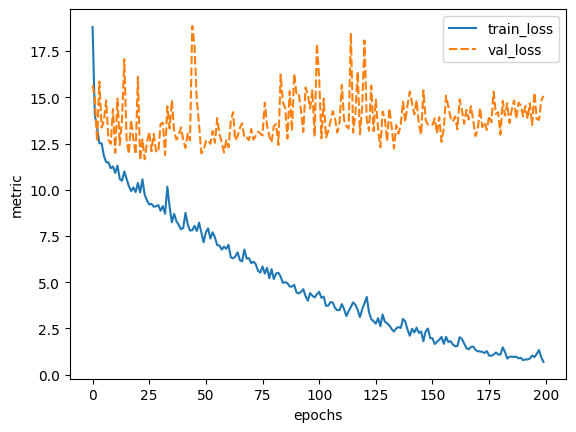

In [23]:
plot_history(history, ['train_loss', 'val_loss'])

### 9.2 Counteract model overfitting

#### 9.2.1 Reduce number of parameters

In [24]:
# Create smaller model
model_small = WeatherPredictionModel(input_size=X_data.shape[1], hidden1=10, hidden2=5)
print(model_small)

WeatherPredictionModel(
  (input_layer): Linear(in_features=89, out_features=10, bias=True)
  (hidden1): Linear(in_features=10, out_features=5, bias=True)
  (hidden2): Linear(in_features=5, out_features=1, bias=True)
  (relu): ReLU()
)


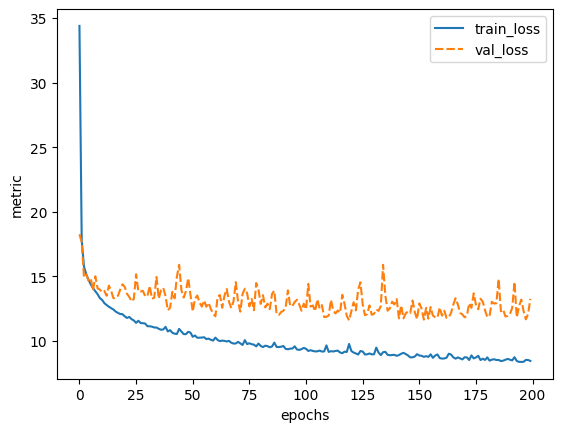

In [25]:
optimizer_small, criterion_small = get_optimizer_and_loss(model_small)
history_small = train_model(model_small, train_loader, val_loader, optimizer_small, criterion_small, epochs=200, verbose=0)
plot_history(history_small, ['train_loss', 'val_loss'])

#### 9.2.2 Early stopping: stop when things are looking best

In [26]:
# Create model with early stopping
model_early = WeatherPredictionModel(input_size=X_data.shape[1])
optimizer_early, criterion_early = get_optimizer_and_loss(model_early)

history_early = train_model(model_early, train_loader, val_loader, optimizer_early, criterion_early, 
                           epochs=200, verbose=0, early_stopping_patience=10)

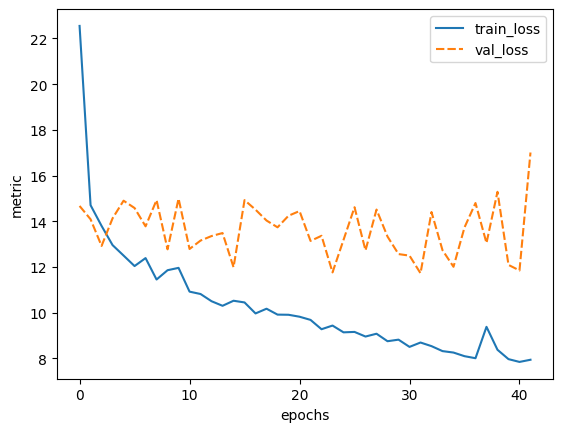

In [27]:
plot_history(history_early, ['train_loss', 'val_loss'])

#### 9.2.3 BatchNorm: the `standard scaler` for deep learning

In [28]:
# Create model with batch normalization
model_batchnorm = WeatherPredictionModel(input_size=X_data.shape[1], use_batchnorm=True)
print(model_batchnorm)

WeatherPredictionModel(
  (input_layer): Linear(in_features=89, out_features=100, bias=True)
  (batchnorm): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (hidden1): Linear(in_features=100, out_features=50, bias=True)
  (hidden2): Linear(in_features=50, out_features=1, bias=True)
  (relu): ReLU()
)


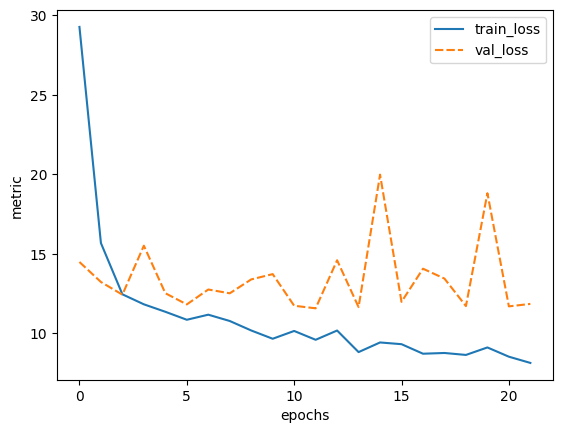

In [29]:
optimizer_batchnorm, criterion_batchnorm = get_optimizer_and_loss(model_batchnorm)
history_batchnorm = train_model(model_batchnorm, train_loader, val_loader, optimizer_batchnorm, criterion_batchnorm, 
                               epochs=1000, verbose=0, early_stopping_patience=10)

plot_history(history_batchnorm, ['train_loss', 'val_loss'])

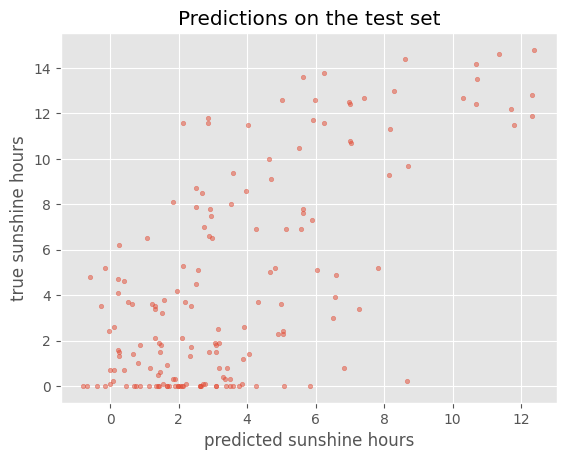

In [30]:
# Evaluate on test set
test_results = evaluate_model(model_batchnorm, test_loader, criterion_batchnorm)
plot_predictions(test_results['predictions'], test_results['labels'], title='Predictions on the test set')

### 9.3 Simplify the model and add data

In [31]:
cols = [c for c in X_data.columns if c[:5] == 'BASEL']
X_data = X_data[cols]

In [32]:
# use 9 years out of the dataset

nr_rows = 365*9
# data
X_data = data.loc[:nr_rows].drop(columns=['DATE', 'MONTH'])

# labels (sunshine hours the next day)
y_data = data.loc[1:(nr_rows + 1)]["BASEL_sunshine"]

In [33]:
# only use columns with 'BASEL'

cols = [c for c in X_data.columns if c[:5] == 'BASEL']
X_data = X_data[cols]

In [34]:
# Rerun the model and evaluate it

X_train, X_holdout, y_train, y_holdout = train_test_split(X_data, y_data, test_size=0.3, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_holdout, y_holdout, test_size=0.5, random_state=0)

# Create data loaders
train_loader, val_loader, test_loader, scaler = prepare_data_loaders(X_train, y_train, X_val, y_val, X_test, y_test)

# create the network and view its summary
model_final = WeatherPredictionModel(input_size=X_data.shape[1], use_batchnorm=True)
print(model_final)

WeatherPredictionModel(
  (input_layer): Linear(in_features=9, out_features=100, bias=True)
  (batchnorm): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (hidden1): Linear(in_features=100, out_features=50, bias=True)
  (hidden2): Linear(in_features=50, out_features=1, bias=True)
  (relu): ReLU()
)


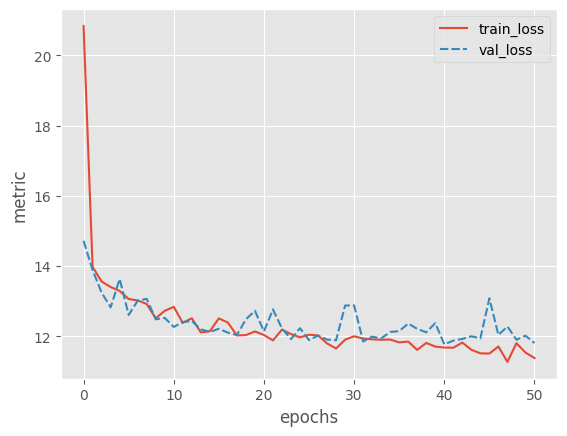

In [35]:
optimizer_final, criterion_final = get_optimizer_and_loss(model_final)
history_final = train_model(model_final, train_loader, val_loader, optimizer_final, criterion_final, 
                          epochs=1000, verbose=0, early_stopping_patience=10)

plot_history(history_final, ['train_loss', 'val_loss'])

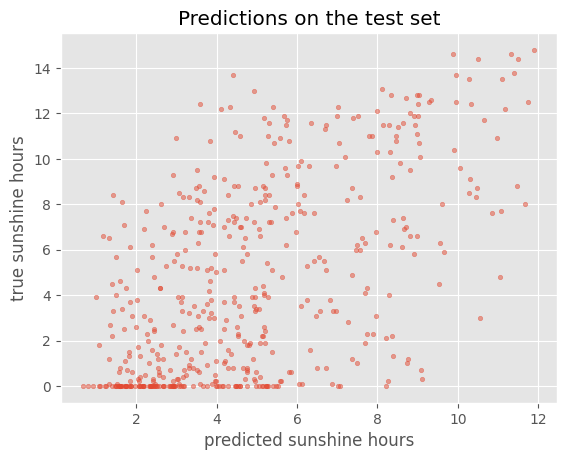

In [36]:
test_results_final = evaluate_model(model_final, test_loader, criterion_final)
plot_predictions(test_results_final['predictions'], test_results_final['labels'], title='Predictions on the test set')

In [37]:
# Compute the RMSE on the test set:
print(f'Test RMSE: {test_results_final["rmse"]}')

Test RMSE: 3.447339653106414


In [38]:
# TensorBoard logging
from torch.utils.tensorboard import SummaryWriter


log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
writer = SummaryWriter(log_dir=log_dir)

def train_with_tensorboard(model, train_loader, val_loader, optimizer, criterion, epochs=200, verbose=1):
    model = model.to(device)
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            # Log to TensorBoard
            if batch_idx % 10 == 0:
                writer.add_scalar('training loss', loss.item(), epoch * len(train_loader) + batch_idx)
        
        train_loss = running_loss / len(train_loader)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_loss += criterion(outputs.squeeze(), labels).item()
        
        val_loss = val_loss / len(val_loader)
        
        # Log to TensorBoard
        writer.add_scalar('validation loss', val_loss, epoch)
        
        if verbose:
            print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
    
    writer.close()
    return {'train_loss': [train_loss], 'val_loss': [val_loss]}

# Example usage:
# train_with_tensorboard(model, train_loader, val_loader, optimizer, criterion)

## 10. Save the model

In [39]:
trained_model_path = "weather_prediction_model_pytorch.pt"
torch.save(model_final.state_dict(), trained_model_path)
print(f"Model saved to {trained_model_path}")

Model saved to weather_prediction_model_pytorch.pt
